# Random Forest DCA-like features - target ln(OIL) - 1000 day forecast

Target = ln(next smoothed OIL). Forecast recursively predicts ln(OIL), then converts back to OIL using exp(prediction).

All notebooks use the same `build_features()` feature engineering style:

- current smoothed oil
- current ln oil
- rolling mean / median / std
- rolling log-slope
- oil-rate ratios

Forecast horizon is fixed at **1000 days**. The forecast is recursive: each predicted future oil rate is appended to history, and the next row of features is built from the updated history.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [2]:
def load_data(path=None):
    """Load oil-rate data and create a smoothed DCA-like decline trend."""
    if path is None:
        path = "/home/rian/python_project/myvenv/dca_ml/data/test_data.csv"

    # Portable fallback for this notebook when run outside your local project folder.
    if not os.path.exists(path):
        fallback = "/mnt/data/test_data(1).csv"
        if os.path.exists(fallback):
            path = fallback

    df = pd.read_csv(path)
    df["TEST_DATE"] = pd.to_datetime(df["TEST_DATE"], format="%d-%b-%y")
    df = df.sort_values("TEST_DATE").dropna(subset=["OIL"]).reset_index(drop=True)
    df = df[df["OIL"] > 0].reset_index(drop=True)

    # Smoothing is used to make the ML forecast behave like a DCA trend.
    df["OIL_SMOOTH"] = df["OIL"].rolling(window=7, min_periods=1).median()
    df["OIL_SMOOTH"] = df["OIL_SMOOTH"].clip(lower=1e-6)
    return df


def visualize_data(df, save_path=None):
    plt.figure(figsize=(12, 6))
    sns.lineplot(x="TEST_DATE", y="OIL", data=df, label="Raw OIL", alpha=0.45)
    sns.lineplot(x="TEST_DATE", y="OIL_SMOOTH", data=df, label="Smoothed OIL / DCA trend")
    plt.title("Oil Production Over Time")
    plt.xlabel("Date")
    plt.ylabel("Oil Production")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


In [3]:
def build_features(q_series, idx):
    """Build DCA-like ML features from oil-rate history up to index idx only.

    Features follow the dcalike.py idea: current rate, log current rate,
    rolling statistics, log-slope, and oil-rate ratio statistics.
    """
    arr = np.asarray(q_series[: idx + 1], dtype=float)
    arr = np.clip(arr, 1e-6, None)
    logq = np.log(arr)

    features = {
        "t": idx,
        "q_current": arr[-1],
        "logq_current": logq[-1],
    }

    for w in [3, 7, 14, 30]:
        sub = arr[-w:]
        lsub = logq[-w:]

        features[f"roll_mean_{w}"] = np.mean(sub)
        features[f"roll_median_{w}"] = np.median(sub)
        features[f"roll_std_{w}"] = np.std(sub) if len(sub) > 1 else 0.0

        if len(lsub) >= 2:
            x = np.arange(len(lsub))
            features[f"log_slope_{w}"] = np.polyfit(x, lsub, 1)[0]
        else:
            features[f"log_slope_{w}"] = 0.0

    if len(arr) >= 2:
        ratios = arr[1:] / arr[:-1]
        for w in [3, 7, 14, 30]:
            r = ratios[-w:]
            features[f"ratio_mean_{w}"] = np.mean(r)
            features[f"ratio_median_{w}"] = np.median(r)
    else:
        for w in [3, 7, 14, 30]:
            features[f"ratio_mean_{w}"] = 1.0
            features[f"ratio_median_{w}"] = 1.0

    return features


In [4]:
def create_dataset(df, minimum_history=30):
    """Create supervised ML data using build_features().

    Target = ln(next smoothed OIL). Forecast recursively predicts ln(OIL), then converts back to OIL using exp(prediction).
    Features are built only from smoothed oil history up to time t.
    """
    work = df.copy()
    work["OIL_NEXT"] = work["OIL_SMOOTH"].shift(-1)
    work["NEXT_TEST_DATE"] = work["TEST_DATE"].shift(-1)
    work["DELTA_T"] = (work["NEXT_TEST_DATE"] - work["TEST_DATE"]).dt.total_seconds() / 86400.0
    work.loc[work["DELTA_T"] <= 0, "DELTA_T"] = np.nan

    work["LN_OIL_TARGET"] = np.log(work["OIL_NEXT"].clip(lower=1e-6))

    work = work.dropna(subset=["LN_OIL_TARGET", "OIL_NEXT", "NEXT_TEST_DATE", "DELTA_T"]).reset_index(drop=True)

    q = work["OIL_SMOOTH"].to_numpy(dtype=float)
    rows = []
    targets = []
    target_indices = []

    for i in range(minimum_history, len(work) - 1):
        rows.append(build_features(q, i))
        targets.append(work["LN_OIL_TARGET"].iloc[i])
        target_indices.append(i)

    X = pd.DataFrame(rows)
    y = np.asarray(targets, dtype=float)
    target_indices = np.asarray(target_indices, dtype=int)

    return X, y, target_indices, work


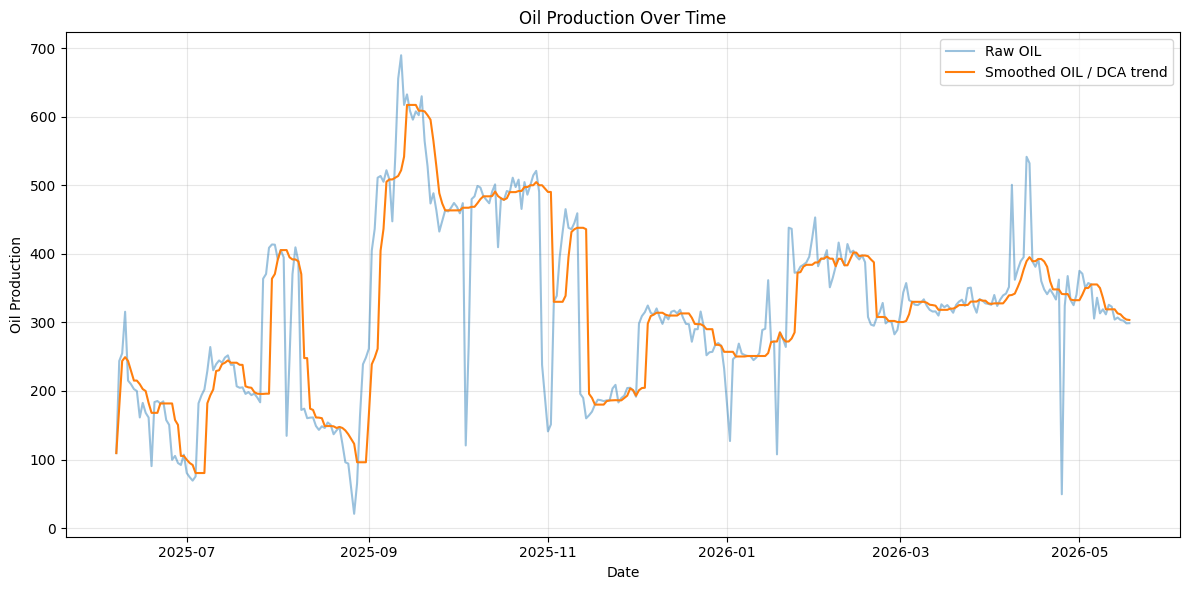

Saved feature dataset to: /home/rian/python_project/myvenv/dca_ml/data/rf03_target_ln_oil_feature_dataset.csv
Feature matrix shape: (311, 27)
Target shape        : (311,)
Random Forest training completed.

Test performance evaluated on OIL scale
Test OIL MAE : 9.8639
Test OIL MSE : 152.8121
Test OIL RMSE: 12.3617
Test OIL R2  : 0.7059


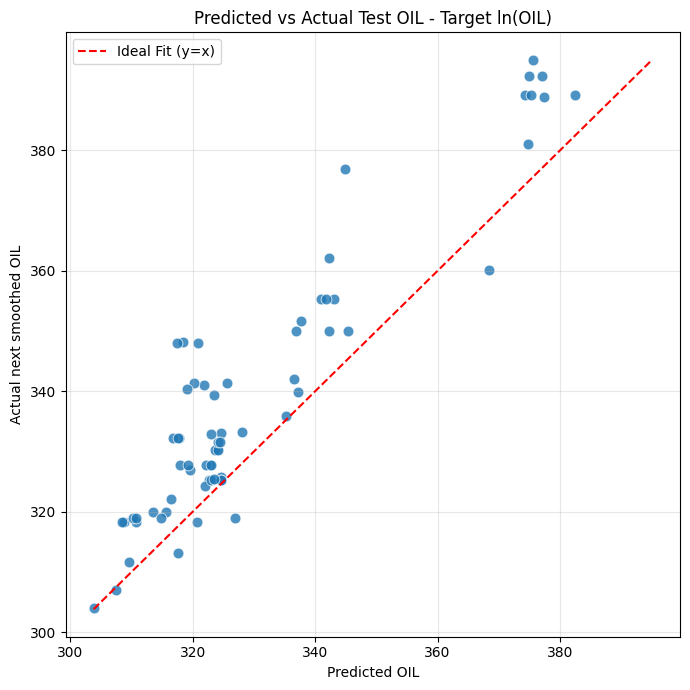

Saved recursive forecast to: /home/rian/python_project/myvenv/dca_ml/data/rf03_target_ln_oil_recursive_forecast_1000.csv

Forecast summary
Last smoothed oil : 304.0705
Day-1 forecast oil: 303.4773
Day-1000 forecast : 321.5365
Forecast rows     : 1000

First 10 forecast rows:
   TEST_DATE  PREDICTED_TARGET  FORECAST_OIL
0 2026-05-18          5.715307    303.477259
1 2026-05-19          5.715326    303.483237
2 2026-05-20          5.715311    303.478540
3 2026-05-21          5.723153    305.867679
4 2026-05-22          5.742346    311.794989
5 2026-05-23          5.769762    320.461580
6 2026-05-24          5.783668    324.949039
7 2026-05-25          5.788565    326.544120
8 2026-05-26          5.778448    323.257260
9 2026-05-27          5.774363    321.939257


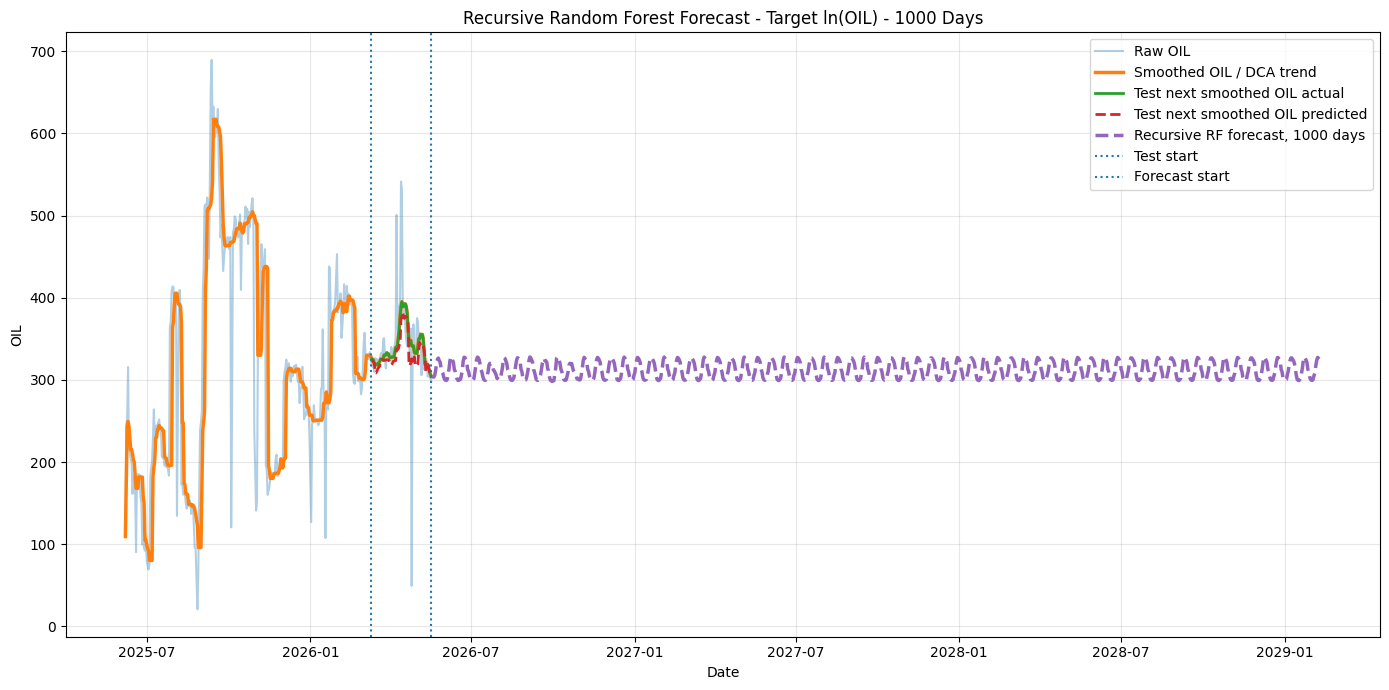

Saved plot to: /home/rian/python_project/myvenv/dca_ml/data/rf03_target_ln_oil_recursive_forecast_1000.png


In [6]:
def main():
    path = "/home/rian/python_project/myvenv/dca_ml/data/test_data.csv"
    df = load_data(path)

    output_dir = "/home/rian/python_project/myvenv/dca_ml/data"
    os.makedirs(output_dir, exist_ok=True)

    visualize_data(df, save_path=os.path.join(output_dir, "rf03_target_ln_oil_raw_vs_smooth.png"))

    minimum_history = 30
    forecast_horizon = 1000

    X_all, y_all, target_indices, model_df = create_dataset(df, minimum_history=minimum_history)

    dataset_out = X_all.copy()
    dataset_out["TARGET"] = y_all
    dataset_out["TEST_DATE"] = model_df["TEST_DATE"].iloc[target_indices].to_numpy()
    dataset_out["OIL_SMOOTH"] = model_df["OIL_SMOOTH"].iloc[target_indices].to_numpy()
    dataset_out["OIL_NEXT"] = model_df["OIL_NEXT"].iloc[target_indices].to_numpy()
    dataset_out["DELTA_T"] = model_df["DELTA_T"].iloc[target_indices].to_numpy()

    dataset_path = os.path.join(output_dir, "rf03_target_ln_oil_feature_dataset.csv")
    dataset_out.to_csv(dataset_path, index=False)

    print(f"Saved feature dataset to: {dataset_path}")
    print(f"Feature matrix shape: {X_all.shape}")
    print(f"Target shape        : {y_all.shape}")

    # Chronological train/test split, same style as rf03.
    train_size = int(len(model_df) * 0.8)
    train_mask = target_indices < train_size
    test_mask = ~train_mask

    X_train, y_train = X_all.loc[train_mask], y_all[train_mask]
    X_test, y_test = X_all.loc[test_mask], y_all[test_mask]
    test_target_indices = target_indices[test_mask]

    # Train Random Forest.
    # Fixed parameters are used so the notebooks run faster and consistently.
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=2,
        min_samples_leaf=2,
        max_features=0.8,
        random_state=42,
        n_jobs=1,
    )
    model.fit(X_train, y_train)
    print("Random Forest training completed.")

    # Test prediction: predict target, then convert prediction back to OIL for evaluation.
    predicted_test_target = model.predict(X_test)

    if "ln" == "oil":
        predicted_test_oil = predicted_test_target
    elif "ln" == "log10":
        predicted_test_oil = 10 ** predicted_test_target
    elif "ln" == "ln":
        predicted_test_oil = np.exp(predicted_test_target)

    predicted_test_oil = np.clip(predicted_test_oil, 1e-6, None)
    actual_test_oil = model_df["OIL_NEXT"].iloc[test_target_indices].to_numpy()
    test_dates = model_df["NEXT_TEST_DATE"].iloc[test_target_indices].to_numpy()

    test_mse = mean_squared_error(actual_test_oil, predicted_test_oil)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(actual_test_oil, predicted_test_oil)
    test_r2 = r2_score(actual_test_oil, predicted_test_oil)

    print("\nTest performance evaluated on OIL scale")
    print(f"Test OIL MAE : {test_mae:.4f}")
    print(f"Test OIL MSE : {test_mse:.4f}")
    print(f"Test OIL RMSE: {test_rmse:.4f}")
    print(f"Test OIL R2  : {test_r2:.4f}")

    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=predicted_test_oil, y=actual_test_oil, s=60, alpha=0.8)
    min_oil = min(predicted_test_oil.min(), actual_test_oil.min())
    max_oil = max(predicted_test_oil.max(), actual_test_oil.max())
    plt.plot([min_oil, max_oil], [min_oil, max_oil], "r--", linewidth=1.5, label="Ideal Fit (y=x)")
    plt.title("Predicted vs Actual Test OIL - Target ln(OIL)")
    plt.xlabel("Predicted OIL")
    plt.ylabel("Actual next smoothed OIL")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "rf03_target_ln_oil_predicted_vs_actual.png"), dpi=200, bbox_inches="tight")
    plt.show()

    # Recursive forecast for exactly 1000 days.
    future_oil_predictions = []
    future_dates = []
    future_predicted_targets = []

    q_history = model_df["OIL_SMOOTH"].to_numpy(dtype=float).tolist()
    current_date = model_df["TEST_DATE"].iloc[-1]

    for step in range(forecast_horizon):
        idx = len(q_history) - 1
        X_future = pd.DataFrame([build_features(q_history, idx)])
        X_future = X_future[X_all.columns]

        predicted_target = float(model.predict(X_future)[0])
        q_next = float(np.exp(predicted_target))
        q_next = max(q_next, 1e-6)

        next_date = current_date + pd.Timedelta(days=1)

        future_predicted_targets.append(predicted_target)
        future_oil_predictions.append(q_next)
        future_dates.append(next_date)

        q_history.append(q_next)
        current_date = next_date

    forecast_df = pd.DataFrame({
        "TEST_DATE": future_dates,
        "PREDICTED_TARGET": future_predicted_targets,
        "FORECAST_OIL": future_oil_predictions,
    })

    forecast_path = os.path.join(output_dir, "rf03_target_ln_oil_recursive_forecast_1000.csv")
    forecast_df.to_csv(forecast_path, index=False)

    print(f"Saved recursive forecast to: {forecast_path}")
    print("\nForecast summary")
    print(f"Last smoothed oil : {model_df['OIL_SMOOTH'].iloc[-1]:.4f}")
    print(f"Day-1 forecast oil: {forecast_df['FORECAST_OIL'].iloc[0]:.4f}")
    print(f"Day-1000 forecast : {forecast_df['FORECAST_OIL'].iloc[-1]:.4f}")
    print(f"Forecast rows     : {len(forecast_df)}")
    print("\nFirst 10 forecast rows:")
    print(forecast_df.head(10))

    plt.figure(figsize=(14, 7))
    plt.plot(model_df["TEST_DATE"], model_df["OIL"], label="Raw OIL", linewidth=1.5, alpha=0.35)
    plt.plot(model_df["TEST_DATE"], model_df["OIL_SMOOTH"], label="Smoothed OIL / DCA trend", linewidth=2.5)

    if len(test_dates) > 0:
        plt.plot(test_dates, actual_test_oil, label="Test next smoothed OIL actual", linewidth=2)
        plt.plot(test_dates, predicted_test_oil, label="Test next smoothed OIL predicted", linewidth=2, linestyle="--")

    plt.plot(forecast_df["TEST_DATE"], forecast_df["FORECAST_OIL"], label="Recursive RF forecast, 1000 days", linewidth=2.5, linestyle="--")
    plt.axvline(model_df["TEST_DATE"].iloc[train_size], linestyle=":", label="Test start")
    plt.axvline(model_df["TEST_DATE"].iloc[-1], linestyle=":", label="Forecast start")
    plt.title("Recursive Random Forest Forecast - Target ln(OIL) - 1000 Days")
    plt.xlabel("Date")
    plt.ylabel("OIL")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plot_path = os.path.join(output_dir, "rf03_target_ln_oil_recursive_forecast_1000.png")
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to: {plot_path}")

    return {
        "model": model,
        "X_all": X_all,
        "y_all": y_all,
        "model_df": model_df,
        "forecast_df": forecast_df,
    }


if __name__ == "__main__":
    main()
